In [3]:
import matplotlib.pyplot as plt
import numpy as np

### TSP with and without parallelization

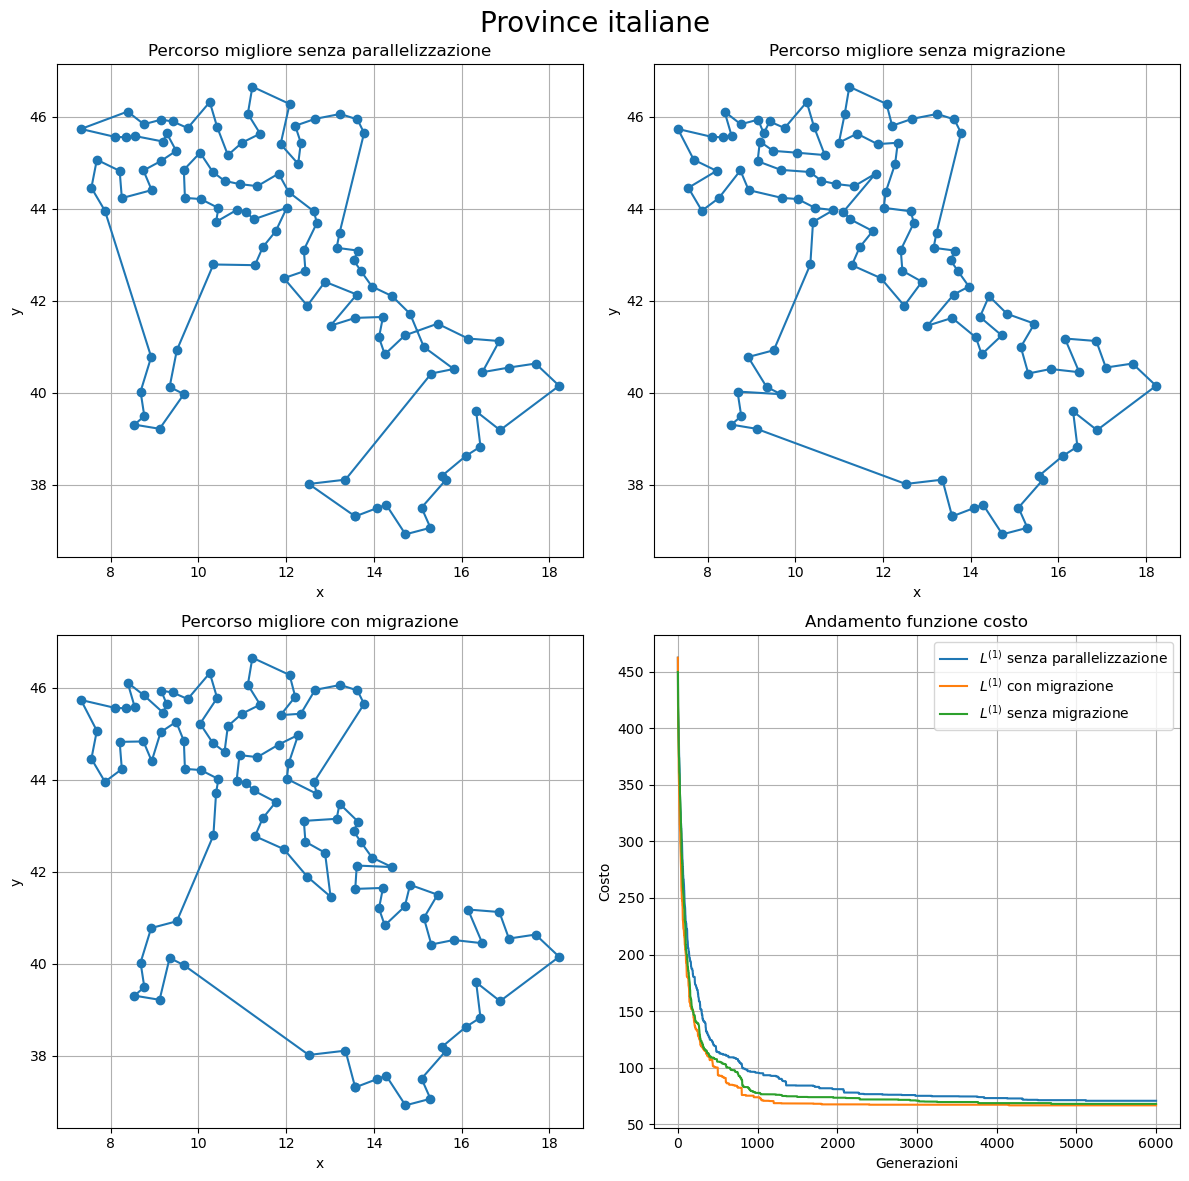

Valore costo finale senza parallelizzazione = 70.9154
Valore costo finale senza migrazione = 68.1718
Valore costo finale con migrazione = 66.89


In [4]:
dati_simple = np.loadtxt("Coordinate_simple.txt")
dati_migr = np.loadtxt("Coordinate_migr.txt")
dati_nomigr = np.loadtxt("Coordinate_nomigr.txt")

x_simple = dati_simple[:, 0]
y_simple = dati_simple[:, 1]
x_s = np.append(x_simple, x_simple[0])
y_s = np.append(y_simple, y_simple[0])
x_migr = dati_migr[:, 0]
y_migr = dati_migr[:, 1]
x_m = np.append(x_migr, x_migr[0])
y_m = np.append(y_migr, y_migr[0])
x_nomigr = dati_nomigr[:, 0]
y_nomigr = dati_nomigr[:, 1]
x_nom = np.append(x_nomigr, x_nomigr[0])
y_nom = np.append(y_nomigr, y_nomigr[0])

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.flatten()

ax[0].plot(x_s, y_s, 'o-')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Percorso migliore senza parallelizzazione")
ax[0].grid(True)

ax[1].plot(x_nom, y_nom, 'o-')
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_title("Percorso migliore senza migrazione")
ax[1].grid(True)

ax[2].plot(x_m, y_m, 'o-')
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
ax[2].set_title("Percorso migliore con migrazione")
ax[2].grid(True)

gen, L_simple = np.loadtxt("./Costi/Costi_simple.txt", usecols=(0,1), unpack=True)
L_migr = np.loadtxt("./Costi/Costi_migr0.txt", usecols=(1), unpack=True)
L_nomigr = np.loadtxt("./Costi/Costi_nomigr2.txt", usecols=(1), unpack=True)

ax[3].plot(gen, L_simple, label=r"$L^{(1)}$ senza parallelizzazione")
ax[3].plot(gen, L_migr, label=r"$L^{(1)}$ con migrazione")
ax[3].plot(gen, L_nomigr, label=r"$L^{(1)}$ senza migrazione")
ax[3].set_xlabel("Generazioni")
ax[3].set_ylabel("Costo")
ax[3].set_title("Andamento funzione costo")
ax[3].grid(True)
ax[3].legend()

fig.suptitle("Province italiane", fontsize= 20)
plt.tight_layout()
plt.show()
print(f"Valore costo finale senza parallelizzazione = {L_simple[-1]}")
print(f"Valore costo finale senza migrazione = {L_nomigr[-1]}")
print(f"Valore costo finale con migrazione = {L_migr[-1]}")

### Commenti
Il codice scritto nella Lezione 9 è stato qui modificato in modo da poterlo eseguire in parallelo su più core. Per far ciò è stata innanzitutto modificata la funzione che si occupa di inizializzare l'algoritmo di generazione di numeri casuali Random, in modo che ciascun rank leggesse una coppia di numeri Primes diversi e svolgesse così simulazioni indipendenti dal principio. Dopodichè si sono implementate le migrazioni tra continenti, una ogni 50 generazioni. Ciascun continente seleziona randomicamente uno tra i migliori individui (seguendo sempre la distribuzione $x^3$ di Lezione 9) e spedisce quest'ultimo al continente successivo mentre riceve quello spedito dal continente precedente.\
Sono state eseguite tre simulazioni da 6000 generazioni e 100 individui, distinguendo il caso di non parallelizzazione, parallelizzazione senza migrazioni e parallelizzazione con migrazioni. Quando parallelizzato, il programma è stato eseguito con 11 core servendosi di un collegamento da remoto al computer di laboratorio. Il percorso finale è quello corrispondente al miglior individuo tra tutti i continenti, trovato grazie alla funzione MPI_Allreduce. Come si può vedere dall'andamento delle funzioni costo e dai valori stampati sotto, il caso di parallelizzazione con migrazione risulta essere il più efficiente tra i tre.